# Структура данных LazyFrame

Импорт библиотек

In [1]:
import polars as pl

**Polars LazyFrame** — это концепция ленивых вычислений, которая обеспечивает эффективный способ обработки больших наборов данных.

В отличие от традиционных *DataFrame*, *LazyFrame* не содержат данных, а вместо этого хранят набор инструкций, известный как план запроса. Планы запросов выполняют операции, такие как фильтрация по условию (предикат) и выбор столбцов (проекция), обеспечивая обработку только тех строк и столбцов, которые действительно необходимы. *LazyFrame* также поддерживают параллельное выполнение планов запросов, что дополнительно повышает производительность.

## Создание LazyFrame

Для создания LazyFrame используют конструктор класса **LazyFrame**, который определяет план вычислений, но не выполняет его сразу.

```python
polars.LazyFrame(
    data=None,
    schema=None,
    schema_overrides=None,
    strict=True,
    orient=None,
    infer_schema_length=100,
    nan_to_null=False,
)
```

|Параметр |	Тип / Возможные значения |	Описание |
| --- | --- | --- |
|**data** | dict, Sequence, Series, numpy.ndarray, pandas.DataFrame или None | Входные данные для создания LazyFrame |
|**schema** | Sequence[str], List[Tuple[str, DataType]], Dict[str, DataType] или None | Определяет структуру LazyFrame: имена столбцов и их типы. Если тип указан как None, то он будет определён автоматически. Можно переопределить имена столбцов, не совпадающих с данными. |
|**schema_overrides** | Dict[str, DataType], List[DataType] или None | Позволяет явно указать типы для определённых столбцов, переопределяя автоматически выведенные. Полезно при работе с неоднородными или проблемными данными. |
|**strict** | bool | Если True, то возникает ошибка при несоответствии типов. Если False - polars попытается мягко преобразовать данные (с обрезкой илизаменой на null |
|**orient** | {'col', 'row'} или None | Указывает ориентацию входных данных. 'row' — данные представлены как список строк, 'col' — как список столбцов. Автоматически определяется, если не указано. | 
|**infer_schema_length** | int или None | Количество строк, используемых для определения типов данных, если schema не задан. По умолчанию 100. Если None — анализируются все строки (создание DataFrame заёмет больше времени). | 
|**nan_to_null** | bool | Если True, преобразует значения NaN в "нуллы" Polars (null/None). Полезно при работе с данными из Pandas. |


Создать *LazyFrame* можно разными способами:
- из словаря;
- из списка словарей;
- из списка списков;
- из структур Series;
- из массива NumPy;
- из другого фрейма данных.

Создание *LazyFrame* аналогично классическому фрейму данных. Покажем на примере словаря.

### Создание LazyFrame из словаря

In [2]:
# Создадим словарь
dict_data = {
    "имя": ["Алексей", "Мария", "Иван"],
    "возраст": [25, 30, 22],
    "город": ["Москва", "Санкт-Петербург", "Казань"]
}

# Создание pl.DataFrame из словаря
lf = pl.LazyFrame(data=dict_data)

# Вывод DataFrame
print(lf)

naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

DF ["имя", "возраст", "город"]; PROJECT */3 COLUMNS


В примере создан *LazyFrame* из словаря — то есть описаны данные, но не начали их обрабатывать. 
Разберём план запроса:
1. `naive plan` — «наивный план» - это план операций, который *Polars* может выполнить в будущем. 
2. `DF ["имя", "возраст", "город"]` - означает, что есть источник данных - фрейм данных с тремя столбцами: "имя", "возраст", "город". *Polars* знает структуру, но не загружал данные в память — он просто «видит» схему.
3. `PROJECT */3 COLUMNS` - PROJECT — это термин из мира баз данных. Он означает, какие столбцы выбрать (* — значит «все столбцы»).

Чтобы получить данные, необходимо вызвать метод `collect()`.

In [3]:
lf.collect()

имя,возраст,город
str,i64,str
"""Алексей""",25,"""Москва"""
"""Мария""",30,"""Санкт-Петербург"""
"""Иван""",22,"""Казань"""


При вызове метода `collect()` мы материализуем наши данные, т.е. получаем классический *DataFrame*.

In [4]:
print(type(lf.collect()))

<class 'polars.dataframe.frame.DataFrame'>


Ещё раз как работает *LazyFrame*:
1. Получаем описание данных.
2. Получаем набор инструкций.
3. Вызываем метод `collect()` для запуска вычислений с целью получения необходимой выборки данных.

## Атрибуты и методы LazyFrame

Основное отличие классического *DataFrame* от *LazyFrame* состоит в том, что во втором случае данные не будут доступны вплоть до момента фактического вычисления. Это значит, что не весь функционал будет доступен из *DataFrame*.

### Атрибуты LazyFrame

Из всех атрибутов, доступных для классического *DataFrame*, *LazyFrame* не имеют доступа только к атрибутам `shape`, `height` и `flags`. Первые два связаны с размером датафрейма, который станет известен только при получении данных, а атрибут `flags` представляет собой словарь с  индикаторами, такими как признак сортировки объекта *Series*, который используется движком для оптимизации.

Доступные атрибуты: 
- `columns` - возвращает список названий столбцов фрейма данных.
- `dtypes` - возвращает список типов данных для каждого столбца.
- `schema` - возвращает словарь, где ключи — имена столбцов, а значения — их типы данных.
- `width` - возвращает ширину таблицы (количество столбцов фрейма данных).

Эти атрибуты доступны в *LazyFrame*, потому что они описывают структуру данных, а не их содержимое.

### Методы LazyFrame

Доступны следующие методы построения запроса (основное назначение):
1. Фильтрация и отбор:
   - `filter()`, `select()`, `drop()`, `rename()`, `slice()`, `limit()`, `head()`, `tail()`, `sort()`, `unique()`, `reverse()`, `shift()`;
2. Группировки и агрегации:
   - `group_by().agg()`, `count()`, `sum()`, `mean()`, `min()`, `max()`, `median()`, `quantile()`, `std()`, `var()`;
3. Объединения:
   - `join()`, `join_asof()`, `join_where()`;
4. Трансформации:
   - `with_columns()`, `unpivot()`, `explode()`, `fill_null()`, `fill_nan()`, `interpolate()`, `rolling()`, `set_sorted()`;
5. Оптимизация и анализ плана:
   * `explain()` — показать оптимизированный план запроса,
   * `show_graph()` — визуализировать план в виде графа,
   * `collect_schema()` — получить схему без выполнения запроса.

*LazyFrame* не имеют методы экспорта (`to_pandas()`, `to_numpy()`, `to_dict()` и т.д.), так как данных ещё нет. Также отсутствуют:
- горизонтальные агрегации (`sum_horizontal()`, `max_horizontal()` и т.д.);
- поэлементные вычисления (`fold()`, `hash_rows()`);
- итерации (`__iter__()`, `iter_rows()`, `row()`, `item()`);
- методы изменения на месте;
- cтатистики и описания;
- прямой доступ к столбцам (`get_column()`, `to_series()`).

## Переход от LazyFrame к DataFrame и обратно

Polars даёт возможность свободно переключаться между ленивым (*LazyFrame*) и жадным (*DataFrame*) режимами — и это одно из главных преимуществ библиотеки. Это позволяет совмещать гибкость немедленных вычислений с мощью оптимизированных ленивых запросов. Методы, которые позволяют это осуществить представлены на картинке ниже.



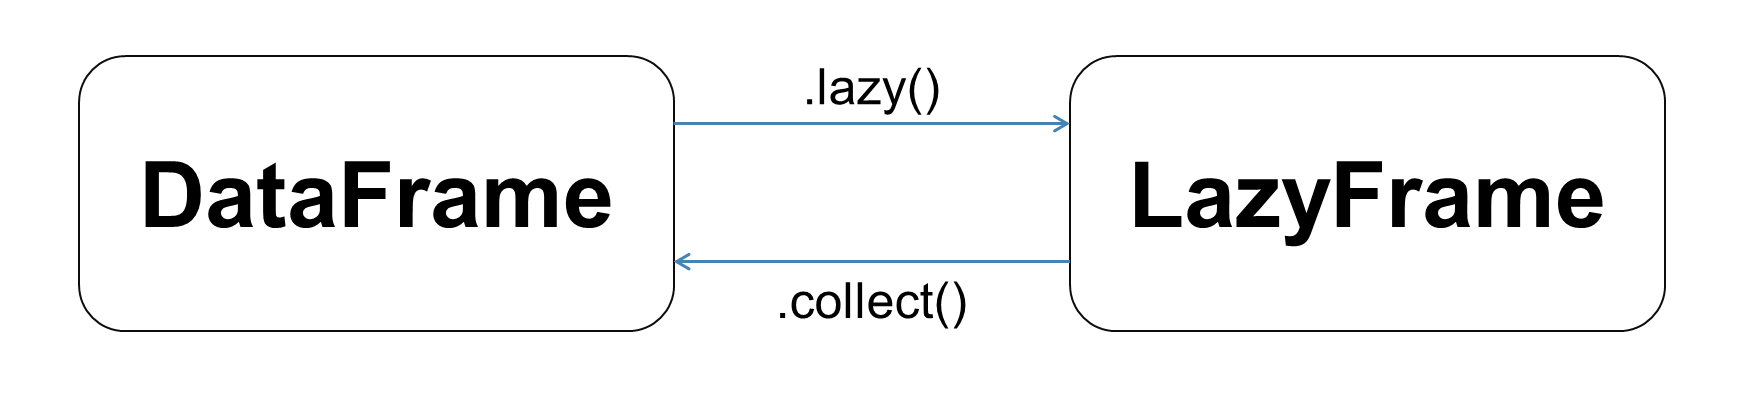

Рассмотрим на примере. Создаём обычный *DataFrame*.

In [5]:
# Исходный жадный DataFrame
df = pl.DataFrame({
    "id": [1, 2, 3, 4, 5],
    "name": ["Алиса", "Вероника", "Игорь", "Ми", "Ян"],
    "salary": [70000, 80000, 120000, 95000, 60000]
})

print(df)

shape: (5, 3)
┌─────┬──────────┬────────┐
│ id  ┆ name     ┆ salary │
│ --- ┆ ---      ┆ ---    │
│ i64 ┆ str      ┆ i64    │
╞═════╪══════════╪════════╡
│ 1   ┆ Алиса    ┆ 70000  │
│ 2   ┆ Вероника ┆ 80000  │
│ 3   ┆ Игорь    ┆ 120000 │
│ 4   ┆ Ми       ┆ 95000  │
│ 5   ┆ Ян       ┆ 60000  │
└─────┴──────────┴────────┘


Здесь все данные уже загружены в память. Любая операция выполнится немедленно. Теперь переходим в ленивый режим - `.lazy()`.

In [6]:
# Переводим в LazyFrame
lazy_df = df.lazy()

print("Тип после .lazy():", type(lazy_df))

Тип после .lazy(): <class 'polars.lazyframe.frame.LazyFrame'>


Теперь `lazy_df` - это логический план, а не данные. Никакие вычисления не выполняются - даже если мы добавим фильтры, сортировки или агрегации.

In [7]:
query = (
    lazy_df
    .filter(pl.col("salary") > 70000)      # фильтруем
    .sort("salary", descending=True)       # сортируем
    .select(["name", "salary"])            # выбираем столбцы
)

print(query)

naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

SELECT [col("name"), col("salary")]
FROM
  SORT BY [col("salary")]
    FILTER [(col("salary")) > (70000)]
    FROM
      DF ["id", "name", "salary"]; PROJECT */3 COLUMNS


В этом и есть сила ленивых вычислений: *polars* анализирует весь запрос целиком и оптимизирует его — например, может сначала выбрать столбцы, потом фильтровать, чтобы меньше данных обрабатывать. Возвращаемся к жадному режиму - `.collect()`.

In [8]:
# Выполняем запрос — данные материализуются
result_df = query.collect()

print(result_df)

shape: (3, 2)
┌──────────┬────────┐
│ name     ┆ salary │
│ ---      ┆ ---    │
│ str      ┆ i64    │
╞══════════╪════════╡
│ Игорь    ┆ 120000 │
│ Ми       ┆ 95000  │
│ Вероника ┆ 80000  │
└──────────┴────────┘


Теперь у нас снова обычный *DataFrame* - его можно использовать для визуализации, экспорта, ML - где угодно. 